In [53]:
from neuralprophet import NeuralProphet

In [54]:
import json
from numpy import median
import pandas as pd
from datetime import timedelta
import numpy as np

def safe_median(values, warn=True):
    '''
    To avoid issues with None or NaN values when computing the median.
    '''
    values = list(values)
    clean = [v for v in values if v is not None and not pd.isna(v)]

    if warn and len(clean) < len(values):
        print(f"{len(values) - len(clean)} ignored values when computing the median.")

    return median(clean) if clean else np.nan
    
def load_jsonl_cleaned(input_file, max_lines = -1, print_progress=True):
    '''
    Load a JSONL file and convert it into a pandas DataFrame.

    :param input_file: path of the JSONL file to load
    :return: pandas DataFrame
    '''
    rows = []
    cpt = 0 # To satisfy the max_lines constraints
    for file in input_file:
        if cpt == max_lines:
            break
        with open(file, 'r', encoding='utf-8') as f:
            total_lines = sum(1 for _ in f) * len(input_file)
            f.seek(0) # Reset file pointer to the beginning after counting lines
            for line in f:
                if cpt == max_lines:
                    break
                cpt += 1
                line = line.strip()
    
                if print_progress and cpt % 100 == 0:
                    print(f"\rTraitement ligne {cpt}/{total_lines}", end="", flush=True)
                if line:
                    item = json.loads(line) ## Load the JSON content
                    content = next(iter(item.values())) ## Get the first value of the dictionary
                    
                    ## Clean the content and taking the median of all the relevant values in qubits
                    content['t1'] = safe_median(list(map(lambda x: x['t1'], content['qubits'].values())))
                    content['t2'] = safe_median(list(map(lambda x: x['t2'], content['qubits'].values())))
                    content['readout_error'] = safe_median(list(map(lambda x: x['readout_error'], content['qubits'].values())))
                    content['prob_meas0_prep1'] = safe_median(list(map(lambda x: x['prob_meas0_prep1'], content['qubits'].values())))
                    content['prob_meas1_prep0'] = safe_median(list(map(lambda x: x['prob_meas1_prep0'], content['qubits'].values())))
                    content.pop('qubits', None)
    
                    ## Clean and taking cols according to the EDA 
                    ### Take the id gates as a referential for single gates metrics
                    if 'id' not in content.get('gates', {}):
                        content['single_gates'] = np.nan
                    else:   
                        content['single_gates'] = safe_median(list(map(lambda x: x['error'], content['gates']['id'].values())))
                    
                    if 'cz' not in content.get('gates', {}):
                        content['cz_error'] = np.nan
                    else:
                        content['cz_error'] = safe_median(list(map(lambda x: x['error'], content['gates']['cz'].values())))
                        
                    if 'rzz' not in content.get('gates', {}):
                        content['rzz_error'] = np.nan
                    else:
                        content['rzz_error'] = safe_median(list(map(lambda x: x['error'], content['gates']['rzz'].values())))
    
                    content.pop('gates', None)
                    
                    rows.append(content)

    df = pd.DataFrame(rows)
    df['calibration_time'] = pd.to_datetime(df['calibration_time'], format='%Y-%m-%d_%H:%M:%S')
    df = df.drop_duplicates(subset=['calibration_time', 'backend'])

    ## Sort each backend by calibration time and backend name
    df_torino = df[df['backend'] == 'ibm_torino'].copy()
    df_torino = df_torino.sort_values('calibration_time').reset_index(drop=True)
    df_torino.ffill(inplace=True)
    
    df_fez = df[df['backend'] == 'ibm_fez'].copy()
    df_fez = df_fez.sort_values('calibration_time').reset_index(drop=True)
    df_fez.ffill(inplace=True)
    
    df_marrakesh = df[df['backend'] == 'ibm_marrakesh'].copy()
    df_marrakesh = df_marrakesh.sort_values('calibration_time').reset_index(drop=True)
    df_marrakesh.ffill(inplace=True)
    
    return df, df_torino, df_fez, df_marrakesh

In [55]:
import os 
from pathlib import Path

'''
Load the dataset and clean it by taking the median of the relevant values in qubits and gates, and then drop the qubits and gates columns.  
We also sort each backend by calibration time and backend name.
This function take a list of files as input so you can either :
- Load a single file by passing a list with one element (ex: [files[1]])
- Load all the files by passing the list of all the files (ex: files)
'''
dataset_folder = Path("../dataset")
files = []
for dirname, _, filenames in os.walk(dataset_folder):
    for filename in filenames:
        files.append(f"{dirname}/{filename}")

weekly_files = [f for f in files if ("weekly_merge" in str(f) and "complete" in str(f))]

df, df_torino, df_fez, df_marrakesh = load_jsonl_cleaned(weekly_files, print_progress=False)

In [56]:
print(f"Dataset loaded with {len(df)} rows.")
print(f"From the {df['calibration_time'].min()} to {df['calibration_time'].max()}.")

Dataset loaded with 9075 rows.
From the 2025-10-29 00:00:00 to 2026-03-04 00:00:00.


In [ ]:
import matplotlib.pyplot as plt

''' 
Outliers detection and cleaning using the IQR method for each metric and each backend.
Quantile are empirically chosen according to the distribution of each metric and the number of outliers detected.
'''

''' --- Fez ---'''
df_out = df_fez.copy()
metric = 'readout_error'
Q1 = df_out[metric].quantile(0.05)
Q3 = df_out[metric].quantile(0.95)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

metric = 'prob_meas0_prep1'
Q1 = df_out[metric].quantile(0.05)
Q3 = df_out[metric].quantile(0.95)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

metric = 'prob_meas1_prep0'
Q1 = df_out[metric].quantile(0.05)
Q3 = df_out[metric].quantile(0.95)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

metric = 'single_gates'
Q1 = df_out[metric].quantile(0.1)
Q3 = df_out[metric].quantile(0.90)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

metric = 'cz_error'
Q1 = df_out[metric].quantile(0.1)
Q3 = df_out[metric].quantile(0.90)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

df_fez = df_out.copy()

''' --- Torino ---'''
df_out = df_torino.copy()

metric = 't2'
Q1 = df_out[metric].quantile(0.1)
Q3 = df_out[metric].quantile(0.90)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

metric = 'readout_error'
Q1 = df_out[metric].quantile(0.1)
Q3 = df_out[metric].quantile(0.90)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

metric = 'prob_meas0_prep1'
Q1 = df_out[metric].quantile(0.1)
Q3 = df_out[metric].quantile(0.90)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

metric = 'prob_meas1_prep0'
Q1 = df_out[metric].quantile(0.15)
Q3 = df_out[metric].quantile(0.85)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

df_torino = df_out.copy()

''' --- Marrakesh ---'''
df_out = df_marrakesh.copy()
metric = 't1'
Q1 = df_out[metric].quantile(0.1)
Q3 = df_out[metric].quantile(0.9)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

metric = 't2'
Q1 = df_out[metric].quantile(0.15)
Q3 = df_out[metric].quantile(0.85)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

metric = 'readout_error'
Q1 = df_out[metric].quantile(0.15)
Q3 = df_out[metric].quantile(0.85)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

metric = 'prob_meas0_prep1'
Q1 = df_out[metric].quantile(0.15)
Q3 = df_out[metric].quantile(0.85)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

metric = 'prob_meas1_prep0'
Q1 = df_out[metric].quantile(0.15)
Q3 = df_out[metric].quantile(0.85)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

df_marrakesh = df_out.copy()

In [58]:
# import torch
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
from random import randint
import  matplotlib.pyplot as plt

device = torch.device("cpu")

def train_val_test_process_for_train(df, steps = 24):
    data = df
    X_train = []
    y_train = []
    
    X_val = []
    y_val = []
    
    X_test = []
    y_test = []
    
    train_test_split = int(0.8 * len(df))
    train_val_split = int(0.8 * train_test_split)
    
    train_raw = data[:train_val_split]
    val_raw = data[train_val_split:train_test_split]
    test_raw = data[train_test_split:]
    
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_raw) # To normalize the data for the Gru model (needs it)

    val_scaled = scaler.transform(val_raw)
    test_scaled = scaler.transform(test_raw)

    train_data = torch.tensor(train_scaled, dtype=torch.float32)
    val_data = torch.tensor(val_scaled, dtype=torch.float32)
    test_data = torch.tensor(test_scaled, dtype=torch.float32)

    for i in range(len(train_data) - steps):
        X_train.append(train_data[i:i+steps])
        y_train.append(train_data[i+steps])
    
    for i in range(len(val_data) - steps):
        X_val.append(val_data[i:i+steps])
        y_val.append(val_data[i+steps])
    
    for i in range(len(test_data) - steps):
        X_test.append(test_data[i:i+steps])
        y_test.append(test_data[i+steps])

    X_train = torch.stack(X_train).to(device) ;y_train = torch.stack(y_train).to(device)
    #print(f'X train shape: {X_train.shape} - y train shape: {y_train.shape}')
    X_val = torch.stack(X_val).to(device); y_val = torch.stack(y_val).to(device)
    #print(f'X val final shape: {X_val.shape} - y val final shape: {y_val.shape}')
    X_test = torch.stack(X_test).to(device);y_test = torch.stack(y_test).to(device)
    #print(f'X test final shape: {X_test.shape} - y test final shape: {y_test.shape}')
    
    return X_train, y_train, X_val, y_val, X_test, y_test

In [59]:
from torch.utils.data import TensorDataset, DataLoader

n_steps = 24
backend = df_fez
metric = 't1'

(X_train, y_train, X_val, y_val, X_test, y_test) = train_val_test_process_for_train(backend[[metric]], steps=n_steps)

n_features = X_train.shape[2]
batch_size = 64

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [60]:
''' 
Taking the median of the relevant values in qubits and gates to have a dataset on a daily basis
'''

df_fez['day'] = df_fez['calibration_time'].dt.date
df_torino['day'] = df_torino['calibration_time'].dt.date
df_marrakesh['day'] = df_marrakesh['calibration_time'].dt.date

metrics = ['t1','t2','readout_error','prob_meas0_prep1','prob_meas1_prep0',
           'single_gates','cz_error','rzz_error']

df_torino_day = df_torino.groupby(['day'])[metrics].median().reset_index()
df_fez_day = df_fez.groupby(['day'])[metrics].median().reset_index()
df_marrakesh_day = df_marrakesh.groupby(['day'])[metrics].median().reset_index()

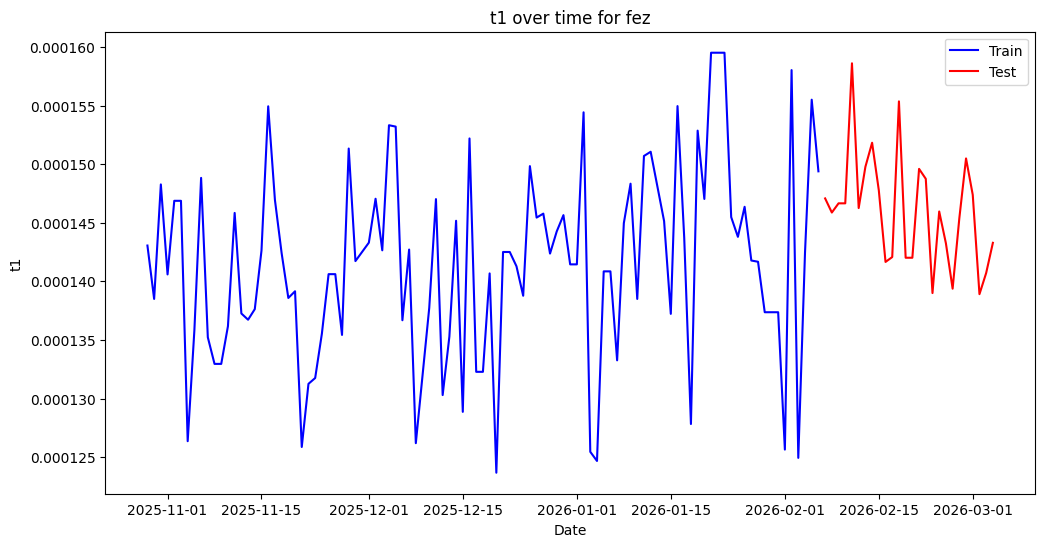

In [61]:
import torch
from neuralprophet import NeuralProphet, set_log_level

df_np_fez = df_fez_day.reset_index()[['day', 't1']]
df_np_fez.columns = ['ds', 'y']

split = int(0.8 * df_np_fez.shape[0])
train_set, test_set = df_np_fez.iloc[:split], df_np_fez.iloc[split:]

plt.figure(figsize=(12,6))
plt.plot(train_set['ds'], train_set['y'], c='blue')
plt.plot(test_set['ds'], test_set['y'], c='red')
plt.title('t1 over time for fez')
plt.xlabel('Date')
plt.ylabel('t1')
plt.legend(['Train', 'Test'])
plt.show()

## Neural Network - Daily

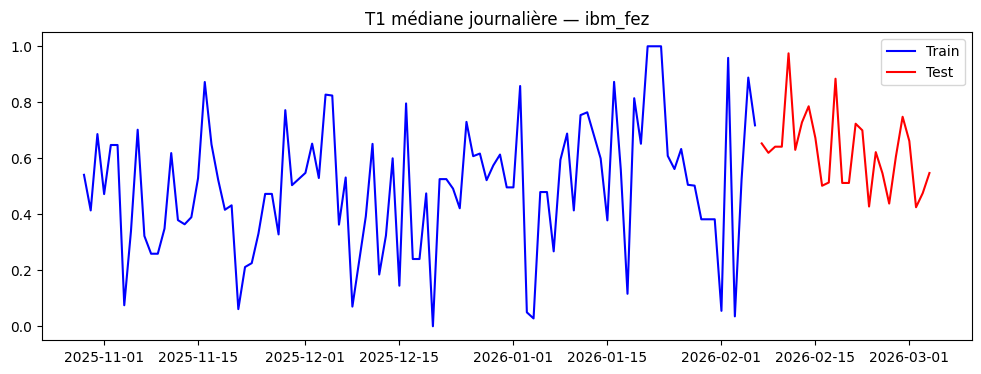

Training: |          | 0/? [00:00<?, ?it/s]

Finding best initial lr: 100%|██████████| 207/207 [00:00<00:00, 261.62it/s]


Training: |          | 0/? [00:17<?, ?it/s, v_num=36, MAE_val=0.197, RMSE_val=0.244, Loss_val=0.214, RegLoss_val=0.000, train_loss=0.0843, reg_loss=0.000, MAE=0.146, RMSE=0.190, Loss=0.0843, RegLoss=0.000]
          MAE      RMSE      Loss   MAE_val  RMSE_val
245  0.146209  0.184289  0.084245  0.196960  0.244202
246  0.146248  0.189501  0.084255  0.196998  0.244157
247  0.146242  0.193994  0.084268  0.196978  0.244102
248  0.146210  0.185846  0.084256  0.197033  0.244173
249  0.146297  0.189505  0.084300  0.197188  0.244437


In [62]:
from neuralprophet import NeuralProphet, set_log_level
from sklearn.preprocessing import MinMaxScaler

set_log_level("ERROR") 

df_np_fez = df_fez_day[['day', 't1']].copy()
df_np_fez.columns = ['ds', 'y']
df_np_fez['ds'] = pd.to_datetime(df_np_fez['ds'])

## Normalising to make the metrics more ''Natural''
scaler = MinMaxScaler()
df_np_fez['y'] = scaler.fit_transform(df_np_fez[['y']])

## train test split
split = int(0.8 * len(df_np_fez))
plt.figure(figsize=(12, 4))
plt.plot(df_np_fez['ds'].iloc[:split], df_np_fez['y'].iloc[:split], c='blue', label='Train')
plt.plot(df_np_fez['ds'].iloc[split:], df_np_fez['y'].iloc[split:], c='red', label='Test')
plt.legend()
plt.title('T1 médiane journalière — ibm_fez')
plt.show()

model = NeuralProphet(
    n_forecasts=1,
    n_lags=7,         
    yearly_seasonality=False,
    weekly_seasonality=True, 
    daily_seasonality=False,
    quantiles=[0.1,0.9]
)

df_train, df_val = model.split_df(df_np_fez, freq='D', valid_p=0.2)
metrics = model.fit(df_train, freq='D', validation_df=df_val)

print(metrics[['MAE', 'RMSE', 'Loss', 'MAE_val', 'RMSE_val']].tail(5))

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 317.92it/s]

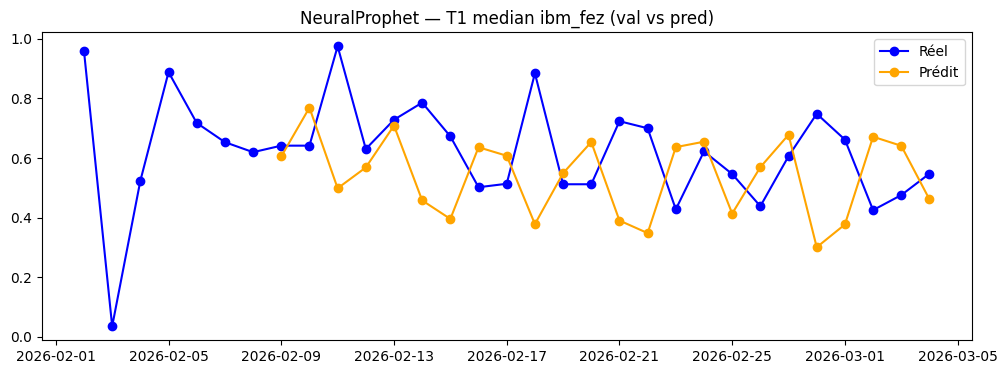

MAE   model  : 1.97e-01
MAE   baseline : 1.11e-01  (predict_mean)
RMSE  model  : 2.44e-01
Ratio MAE/baseline : 1.78


In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Prédictions sur le jeu de validation
df_pred = model.predict(df_val)

plt.figure(figsize=(12, 4))
plt.plot(df_pred['ds'], df_pred['y'], "o-", label='Réel', color='blue')
plt.plot(df_pred['ds'], df_pred['yhat1'], "o-",   label='Prédit',    color='orange')
plt.legend()
plt.title('NeuralProphet — T1 median ibm_fez (val vs pred)')
plt.show()

mask = df_pred['yhat1'].notna() & df_pred['y'].notna()
mae  = mean_absolute_error(df_pred.loc[mask, 'y'], df_pred.loc[mask, 'yhat1'])
rmse = np.sqrt(mean_squared_error(df_pred.loc[mask, 'y'], df_pred.loc[mask, 'yhat1']))
baseline_mae = mean_absolute_error(df_pred.loc[mask, 'y'],
                                   [df_pred.loc[mask, 'y'].mean()] * mask.sum())

print(f"MAE   model  : {mae:.2e}")
print(f"MAE   baseline : {baseline_mae:.2e}  (predict_mean)")
print(f"RMSE  model  : {rmse:.2e}")
print(f"Ratio MAE/baseline : {mae/baseline_mae:.2f}")



In [70]:
mask = df_pred['yhat1'].notna() & df_pred['y'].notna()
y_true = df_pred.loc[mask, 'y'].values
y_pred = df_pred.loc[mask, 'yhat1'].values

y_naive = df_pred.loc[mask, 'y'].shift(1).dropna().values
y_true_naive = y_true[1:]

mae_model = mean_absolute_error(y_true, y_pred)
mae_naive  = mean_absolute_error(y_true_naive, y_naive)
mae_mean   = mean_absolute_error(y_true, [y_true.mean()] * len(y_true))

print(f"MAE model  : {mae_model:.2e}")
print(f"MAE naive    : {mae_naive:.2e}   ← y(t) = y(t-1)")
print(f"MAE mean  : {mae_mean:.2e}   ← y(t) = mean")
print(f"\nModel vs naive : {mae_model/mae_naive:.3f}  (model better if < )")
print(f"\nModel vs mean : {mae_model/mae_mean:.3f}  (model better if < )")

MAE model  : 1.97e-01
MAE naive    : 1.53e-01   ← y(t) = y(t-1)
MAE mean  : 1.11e-01   ← y(t) = mean

Model vs naive : 1.291  (model better if < )

Model vs mean : 1.776  (model better if < )


<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0;">

We achieve the same conclusion as the previous models, the model only learned how to predict t = t-1.  
We can however notice some patter, if the value go to far from the mean, the model will try to go closer.  

We notice a pattern, the prediction looking close to our orignal signal with a time laps of 1.

## Generalising inside a function

In [66]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def neuralProphMetricsComputation(df, feature, print_results=True):
    ''' 
    Compute fit neural prophet model and compute metrics on the test set (MAE, RMSE, baseline MAE) for a given feature and a given dataframe.
    print the metrics and show the plot of the predictions vs the real values for the test set.
    Input: 
    - df: dataframe containing the data for a given backend (ex: df_fez_day)
    - feature: the feature to predict (ex: 't1')
    output: 
    - return the metrics (mae_model, mae_naive, mae_mean, rmse_model, r2_model)
    '''

    set_log_level("ERROR") 

    ''' ---- Data preparation ---- '''
    df_np_fez = df[['day', feature]].copy()
    df_np_fez.columns = ['ds', 'y']
    df_np_fez['ds'] = pd.to_datetime(df_np_fez['ds'])

    n = len(df_np_fez)
    df_trainval = df_np_fez.iloc[:int(n * 0.8)]  # 80%
    df_test = df_np_fez.iloc[int(n * 0.8):]  # 20%

    scaler = MinMaxScaler()
    df_trainval['y'] = scaler.fit_transform(df_trainval[['y']])
    df_test['y'] = scaler.transform(df_test[['y']])

    if print_results:    
        plt.figure(figsize=(12, 4))
        plt.plot(df_trainval['ds'], df_trainval['y'], c='blue', label='Train')
        plt.plot(df_test['ds'], df_test['y'], c='red', label='Test')
        plt.legend()
        plt.title(f'{feature} médiane journalière')
        plt.show()

    ''' ---- Model fitting ---- '''
    model = NeuralProphet(
        n_forecasts=1,
        n_lags=7,         
        yearly_seasonality=False,
        weekly_seasonality=False, 
        daily_seasonality=False,
        quantiles=[0.1,0.9]
    )

    ''' ---- Fitting, Prediction & Evaluation ---- '''
    df_train, df_val = model.split_df(df_trainval, freq='D', valid_p=0.2)
    metrics = model.fit(df_train, freq='D', validation_df=df_val)

    if print_results:
        print(metrics[['MAE', 'RMSE', 'Loss', 'MAE_val', 'RMSE_val']].tail(5))


    df_pred = model.predict(df_test)

    if print_results:
        plt.figure(figsize=(12, 4))
        plt.plot(df_pred['ds'], df_pred['y'], "o-", label='Réel', color='blue')
        plt.plot(df_pred['ds'], df_pred['yhat1'], "o-",   label='Prédit',    color='orange')
        plt.legend()
        plt.title(f'NeuralProphet — {feature} median (val vs pred)')
        plt.show()

    ''' ---- Comparing model with naive and median method ---- '''

    mask = df_pred['yhat1'].notna() & df_pred['y'].notna()
    rmse = np.sqrt(mean_squared_error(df_pred.loc[mask, 'y'], df_pred.loc[mask, 'yhat1']))
    r2 = r2_score(df_pred.loc[mask, 'y'], df_pred.loc[mask, 'yhat1'])

    y_true = df_pred.loc[mask, 'y'].values
    y_pred = df_pred.loc[mask, 'yhat1'].values

    y_naive = df_pred.loc[mask, 'y'].shift(1).dropna().values
    y_true_naive = y_true[1:]

    mae_model = mean_absolute_error(y_true, y_pred)
    mae_naive  = mean_absolute_error(y_true_naive, y_naive)
    mae_mean   = mean_absolute_error(y_true, [y_true.mean()] * len(y_true))

    if print_results:
        print(f"MAE model   : {mae_model:.2e}")
        print(f"MAE naive    : {mae_naive:.2e}   ← y(t) = y(t-1)")
        print(f"MAE mean  : {mae_mean:.2e}   ← y(t) = mean")
        print(f"\nModèle vs naive : {mae_model/mae_naive:.3f}  (model better if < 1)")
        print(f"\nModèle vs mean : {mae_model/mae_mean:.3f}  (model better if < 1)")
        print(f"R²  modèle   : {r2:.2f}")
        print(f"RMSE  modèle   : {rmse:.2e}")
    
    return mae_model, mae_naive, mae_mean, rmse, r2

WARNING - (py.warnings._showwarnmsg) - /tmp/ipykernel_406293/2922262350.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trainval['y'] = scaler.fit_transform(df_trainval[['y']])

WARNING - (py.warnings._showwarnmsg) - /tmp/ipykernel_406293/2922262350.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['y'] = scaler.transform(df_test[['y']])



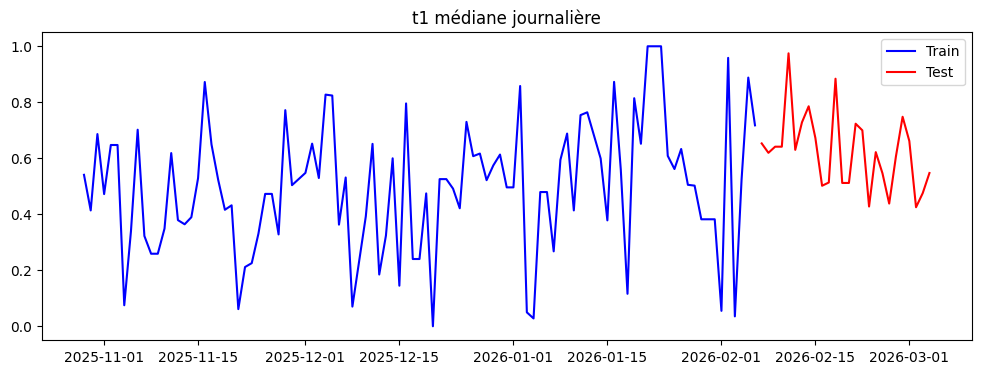

Training: |          | 0/? [00:00<?, ?it/s]

Finding best initial lr: 100%|██████████| 206/206 [00:00<00:00, 217.81it/s]


Training: |          | 0/? [00:18<?, ?it/s, v_num=41, MAE_val=0.224, RMSE_val=0.307, Loss_val=0.300, RegLoss_val=0.000, train_loss=0.0892, reg_loss=0.000, MAE=0.143, RMSE=0.180, Loss=0.0907, RegLoss=0.000]
          MAE      RMSE      Loss   MAE_val  RMSE_val
265  0.144706  0.177783  0.093130  0.223532  0.306979
266  0.143453  0.177475  0.091874  0.223498  0.307032
267  0.136981  0.171573  0.087168  0.223619  0.307202
268  0.146527  0.183272  0.095246  0.223636  0.307209
269  0.143408  0.179517  0.090679  0.223683  0.307327
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 423.15it/s]


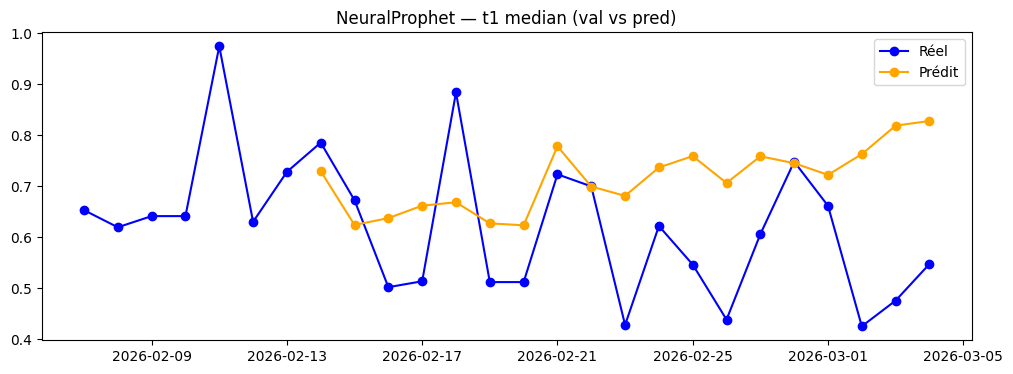

MAE model   : 1.53e-01
MAE naive    : 1.49e-01   ← y(t) = y(t-1)
MAE mean  : 1.10e-01   ← y(t) = mean

Modèle vs naive : 1.031  (model better if < 1)

Modèle vs mean : 1.389  (model better if < 1)
R²  modèle   : -1.10
RMSE  modèle   : 1.86e-01


(0.15340887401766445,
 0.1488462955136996,
 0.11047286662670552,
 0.18554044360580202,
 -1.0982833793778717)

In [ ]:
neuralProphMetricsComputation(df_fez_day, 't1', print_results=True)

In [ ]:
def benchmark_neuralprophet(backends, features, print_results=False):
    '''
    Run neuralProphMetricsComputation for all backends and features
    and store the results in a DataFrame.
    Input:
        - backends: dict {name: dataframe} (ex: {"fez": df_fez_day, ...})
        - features: list of features to predict
    Output:
        - df_benchmark: DataFrame with MAE, MAE_naive, MAE_mean, RMSE, R2 for each backend/feature
    '''
    results = []

    for backend_name, df in backends.items():
        for feature in features:
            print(f"\n=== {backend_name} — {feature} ===")
            try:
                mae_model, mae_naive, mae_mean, rmse, r2 = neuralProphMetricsComputation(df, feature, print_results=print_results)
                results.append({
                    "backend": backend_name,
                    "feature": feature,
                    "MAE_model": mae_model,
                    "MAE_naive": mae_naive,
                    "MAE_mean": mae_mean,
                    "RMSE": rmse,
                    "R2": r2,
                    "ratio_vs_naive": mae_model / mae_naive,
                    "ratio_vs_mean": mae_model / mae_mean
                })
            except Exception as e:
                print(f"Error for {backend_name} — {feature} : {e}")

    df_benchmark = pd.DataFrame(results)
    return df_benchmark

if __name__ == "__main__":
    backends = {
        "fez": df_fez_day,
        "torino": df_torino_day,
        "marrakesh": df_marrakesh_day
    }
    features = ['t1', 't2', 'readout_error', 'prob_meas0_prep1', 
                'prob_meas1_prep0', 'single_gates', 'cz_error', 'rzz_error']

    df_benchmark = benchmark_neuralprophet(backends, features, print_results=True)
    df_benchmark.to_csv("benchmark_neuralprophet.csv", index=False)
    df_benchmark

### Hourly prediction

In [98]:
def neuralProphMetricsComputation_hour(df, feature, print_results=True):
    ''' 
    Fit neural prophet model on hourly data and compute metrics on the test set (MAE, RMSE, baseline MAE) for a given feature and a given dataframe.
    print the metrics and show the plot of the predictions vs the real values for the test set.
    Input: 
    - df: dataframe containing the data for a given backend (ex: df_fez_day)
    - feature: the feature to predict (ex: 't1')
    output: 
    - return the metrics (mae_model, mae_naive, mae_mean, rmse_model, r2_model)
    '''

    set_log_level("ERROR") 

    ''' ---- Data preparation ---- '''
    df_copy = df[['calibration_time', feature]].copy()
    df_copy.columns = ['ds', 'y']
    df_copy['ds'] = pd.to_datetime(df_copy['ds'])

    n = len(df_copy)
    df_trainval = df_copy.iloc[:int(n * 0.8)]  # 80%
    df_test = df_copy.iloc[int(n * 0.8):]  # 20%

    scaler = MinMaxScaler()
    df_trainval['y'] = scaler.fit_transform(df_trainval[['y']])
    df_test['y'] = scaler.transform(df_test[['y']])

    if print_results:    
        plt.figure(figsize=(12, 4))
        plt.plot(df_trainval['ds'], df_trainval['y'], c='blue', label='Train')
        plt.plot(df_test['ds'], df_test['y'], c='red', label='Test')
        plt.legend()
        plt.title(f'{feature} médiane journalière')
        plt.show()

    ''' ---- Model fitting ---- '''
    model = NeuralProphet(
        n_forecasts=1,
        n_lags=7,         
        yearly_seasonality=False,
        weekly_seasonality=False, 
        daily_seasonality=False,
        quantiles=[0.1,0.9]
    )

    ''' ---- Fitting, Prediction & Evaluation ---- '''
    df_train, df_val = model.split_df(df_trainval, freq='h', valid_p=0.2)
    metrics = model.fit(df_train, freq='h', validation_df=df_val)

    if print_results:
        print(metrics[['MAE', 'RMSE', 'Loss', 'MAE_val', 'RMSE_val']].tail(5))


    df_pred = model.predict(df_test)

    if print_results:
        plt.figure(figsize=(12, 4))
        plt.plot(df_pred['ds'], df_pred['y'], "o-", label='Réel', color='blue')
        plt.plot(df_pred['ds'], df_pred['yhat1'], "o-",   label='Prédit',    color='orange')
        plt.legend()
        plt.title(f'NeuralProphet — {feature} median (val vs pred)')
        plt.savefig(f'neuralprophet_{feature}_hourly.png')
        plt.show()

    ''' ---- Comparing model with naive and median method ---- '''

    mask = df_pred['yhat1'].notna() & df_pred['y'].notna()
    rmse = np.sqrt(mean_squared_error(df_pred.loc[mask, 'y'], df_pred.loc[mask, 'yhat1']))
    r2 = r2_score(df_pred.loc[mask, 'y'], df_pred.loc[mask, 'yhat1'])

    y_true = df_pred.loc[mask, 'y'].values
    y_pred = df_pred.loc[mask, 'yhat1'].values

    y_naive = df_pred.loc[mask, 'y'].shift(1).dropna().values
    y_true_naive = y_true[1:]

    mae_model = mean_absolute_error(y_true, y_pred)
    mae_naive  = mean_absolute_error(y_true_naive, y_naive)
    mae_mean   = mean_absolute_error(y_true, [y_true.mean()] * len(y_true))

    if print_results:
        print(f"MAE model   : {mae_model:.2e}")
        print(f"MAE naive    : {mae_naive:.2e}   ← y(t) = y(t-1)")
        print(f"MAE mean  : {mae_mean:.2e}   ← y(t) = mean")
        print(f"\nModèle vs naive : {mae_model/mae_naive:.3f}  (model better if < 1)")
        print(f"\nModèle vs mean : {mae_model/mae_mean:.3f}  (model better if < 1)")
        print(f"R²  modèle   : {r2:.2f}")
        print(f"RMSE  modèle   : {rmse:.2e}")
    
    return mae_model, mae_naive, mae_mean, rmse, r2

WARNING - (py.warnings._showwarnmsg) - /tmp/ipykernel_406293/196742915.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trainval['y'] = scaler.fit_transform(df_trainval[['y']])

WARNING - (py.warnings._showwarnmsg) - /tmp/ipykernel_406293/196742915.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['y'] = scaler.transform(df_test[['y']])



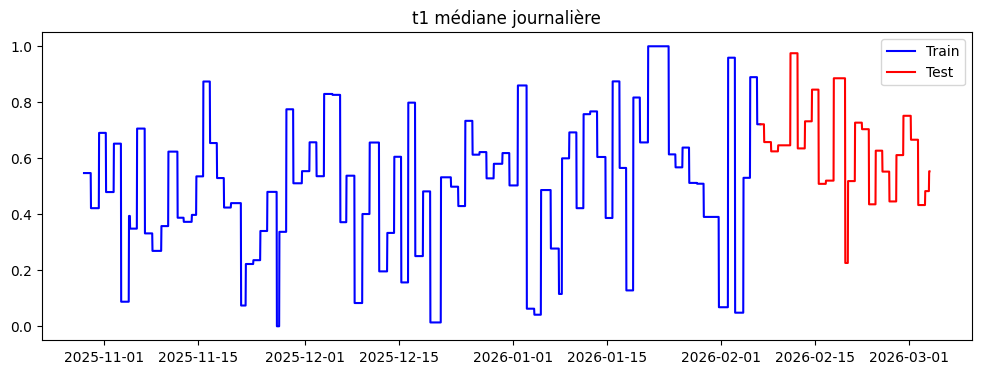

Training: |          | 0/? [00:00<?, ?it/s]

Finding best initial lr: 100%|██████████| 232/232 [00:00<00:00, 253.99it/s]


Training: |          | 0/? [00:22<?, ?it/s, v_num=91, MAE_val=0.0163, RMSE_val=0.0798, Loss_val=0.0192, RegLoss_val=0.000, train_loss=0.0096, reg_loss=0.000, MAE=0.0121, RMSE=0.0447, Loss=0.00963, RegLoss=0.000] 
         MAE      RMSE      Loss   MAE_val  RMSE_val
85  0.012112  0.043449  0.009512  0.016619  0.079779
86  0.013084  0.041782  0.009509  0.016154  0.079809
87  0.012123  0.042721  0.009763  0.015290  0.079878
88  0.012773  0.042004  0.009507  0.016848  0.079765
89  0.012063  0.044664  0.009632  0.016345  0.079796
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 459.20it/s]


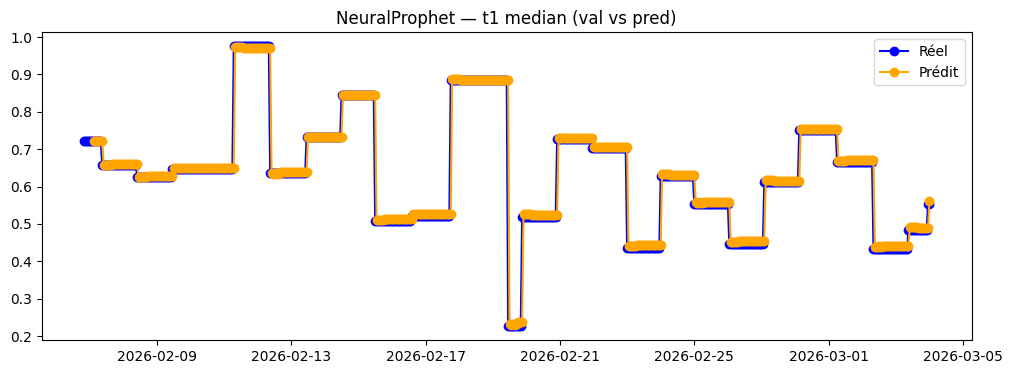

MAE model   : 1.07e-02
MAE naive    : 7.17e-03   ← y(t) = y(t-1)
MAE mean  : 1.17e-01   ← y(t) = mean

Modèle vs naive : 1.486  (model better if < 1)

Modèle vs mean : 0.091  (model better if < 1)
R²  modèle   : 0.91
RMSE  modèle   : 4.65e-02


(0.010655382827628585,
 0.007171089185179138,
 0.11651618520457635,
 0.0464784635899046,
 0.9067185957553748)

In [99]:
neuralProphMetricsComputation_hour(df_fez, 't1', print_results=True)